In [1]:
!pip install vaderSentiment
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
slang_data1 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/FYP/genz_slang.csv')
slang_data2 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/FYP/all_slangs.csv')
sarcasm_data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/FYP/SAMPLE DATASET 50K.csv')

In [ ]:
print(slang_data1.columns)
print(slang_data2.columns)
print(sarcasm_data.columns)

Index(['keyword', 'description'], dtype='object')
Index(['Slang', 'Description', 'Example', 'Context'], dtype='object')
Index(['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs',
       'date', ' ', 'parent_comment'],
      dtype='object')


Data Preprocessing

In [5]:
#Merge slang datasets into a unified dictionary, Standardize columns and Combine descriptions
slang_data2 = slang_data2.rename(columns={'Slang': 'keyword', 'Description': 'description'})
merged_slang = pd.concat([slang_data1[['keyword', 'description']], slang_data2[['keyword', 'description']]], ignore_index=True)
merged_slang = merged_slang.drop_duplicates(subset=['keyword'])  # Remove duplicate keywords

#create a slang dictionary
slang_dict = dict(zip(merged_slang['keyword'].str.lower(), merged_slang['description']))

In [6]:
#drop irrelevant columns
columns_to_drop = [" ", "author","ups","downs","date"]
sarcasm_data = sarcasm_data.drop(columns= columns_to_drop)

In [7]:
#handle missing values and duplicated
print(f"missing values \n {sarcasm_data.isna().sum()}\n")
print(f"duplicate values{sarcasm_data.duplicated().sum()}")

sarcasm_data = sarcasm_data.dropna()
sarcasm_data = sarcasm_data.drop_duplicates()

#rename label to sarcasm_flag
sarcasm_data = sarcasm_data.rename(columns={'label': 'sarcasm_flag'})

missing values 
 label             0
comment           2
subreddit         0
score             0
parent_comment    0
dtype: int64

duplicate values7


In [8]:
#Create 'full_text' by combining 'comment' + 'parent_comment'
sarcasm_data['parent_comment'] = sarcasm_data['parent_comment'].fillna('')
sarcasm_data['full_text'] = sarcasm_data['comment'] + ' [Parent: ' + sarcasm_data['parent_comment'] + ']'

In [9]:
#Function for rule-based slang detection
def detect_slang(comment, slang_dict):
    if not isinstance(comment, str):
        return 0, ''
    words = re.findall(r'\b\w+\b', comment.lower())  # Extract words, ignoring punctuation
    detected = set()  # Use set to avoid duplicate detections
    contexts = []
    for word in words:
        if word in slang_dict:
            detected.add(word)
            contexts.append(f"{word}: {slang_dict[word]}")
    flag = 1 if detected else 0
    context = '; '.join(contexts) if contexts else ''
    return flag, context

#Apply detection to sarcasm_data
sarcasm_data[['slang_flag', 'slang_context']] = sarcasm_data['full_text'].apply(
    lambda x: pd.Series(detect_slang(x, slang_dict))
)

In [10]:
#swtich the column order to be more presentable
columns = sarcasm_data.columns.tolist()
columns.remove('sarcasm_flag')
# Find the index of 'full_text'
full_text_index = columns.index('full_text')
columns.insert(full_text_index + 1, 'sarcasm_flag')
sarcasm_data = sarcasm_data[columns]

sarcasm_data.head()

,comment,subreddit,score,parent_comment,full_text,sarcasm_flag,slang_flag,slang_context
0,NC and NH.,politics,2,"Yeah, I get that argument. At this point, I'd ...","NC and NH. [Parent: Yeah, I get that argument....",0,1,nc: Nice crib ; nh: Nice hand ; at: At your te...
1,You do know west teams play against west teams...,nba,-4,The blazers and Mavericks (The wests 5 and 6 s...,You do know west teams play against west teams...,0,1,know: knowledge
2,"They were underdogs earlier today, but since G...",nfl,3,They're favored to win.,"They were underdogs earlier today, but since G...",0,0,
3,"This meme isn't funny none of the ""new york ni...",BlackPeopleTwitter,-8,deadass don't kill my buzz,"This meme isn't funny none of the ""new york ni...",0,1,are: Acronym rich environment
4,I could use one of those tools.,MaddenUltimateTeam,6,Yep can confirm I saw the tool they use for th...,I could use one of those tools. [Parent: Yep c...,0,1,was: Wait a second


In [11]:
# Sentiment Flag Script
analyzer = SentimentIntensityAnalyzer()

def get_adjusted_sentiment(text, sarcasm_flag):
    if not isinstance(text, str):
        return 0  # Default to neutral
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if sarcasm_flag == 1:
        compound = -compound  # Invert for sarcasm
    if compound >= 0.05:
        return 2  # Positive
    elif compound <= -0.05:
        return 1  # Negative
    else:
        return 0  # Neutral

sarcasm_data['sentiment'] = sarcasm_data.apply(
    lambda row: get_adjusted_sentiment(row['full_text'], row['sarcasm_flag']), axis=1
)
user_comments_data = sarcasm_data

In [12]:
user_comments_data.head()

,comment,subreddit,score,parent_comment,full_text,sarcasm_flag,slang_flag,slang_context,sentiment
0,NC and NH.,politics,2,"Yeah, I get that argument. At this point, I'd ...","NC and NH. [Parent: Yeah, I get that argument....",0,1,nc: Nice crib ; nh: Nice hand ; at: At your te...,2
1,You do know west teams play against west teams...,nba,-4,The blazers and Mavericks (The wests 5 and 6 s...,You do know west teams play against west teams...,0,1,know: knowledge,2
2,"They were underdogs earlier today, but since G...",nfl,3,They're favored to win.,"They were underdogs earlier today, but since G...",0,0,,2
3,"This meme isn't funny none of the ""new york ni...",BlackPeopleTwitter,-8,deadass don't kill my buzz,"This meme isn't funny none of the ""new york ni...",0,1,are: Acronym rich environment,2
4,I could use one of those tools.,MaddenUltimateTeam,6,Yep can confirm I saw the tool they use for th...,I could use one of those tools. [Parent: Yep c...,0,1,was: Wait a second,2


Data Cleaning

In [13]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # URLs
    text = re.sub(r'@\w+', '', text)  # mentions
    text = re.sub(r'#\w+', '', text)   # hashtags (optional – keep if slang-related)
    text = re.sub(r'\s+', ' ', text).strip()  # extra spaces
    return text

user_comments_data['full_text'] = user_comments_data['full_text'].apply(clean_text)

In [14]:
#remove very short comments that are less than 10 character
user_comments_data = user_comments_data[user_comments_data['full_text'].str.strip().str.len() > 10]  # e.g., min 10 chars

#remove duplicated comments
user_comments_data = user_comments_data.drop_duplicates(subset=['full_text'])

EDA

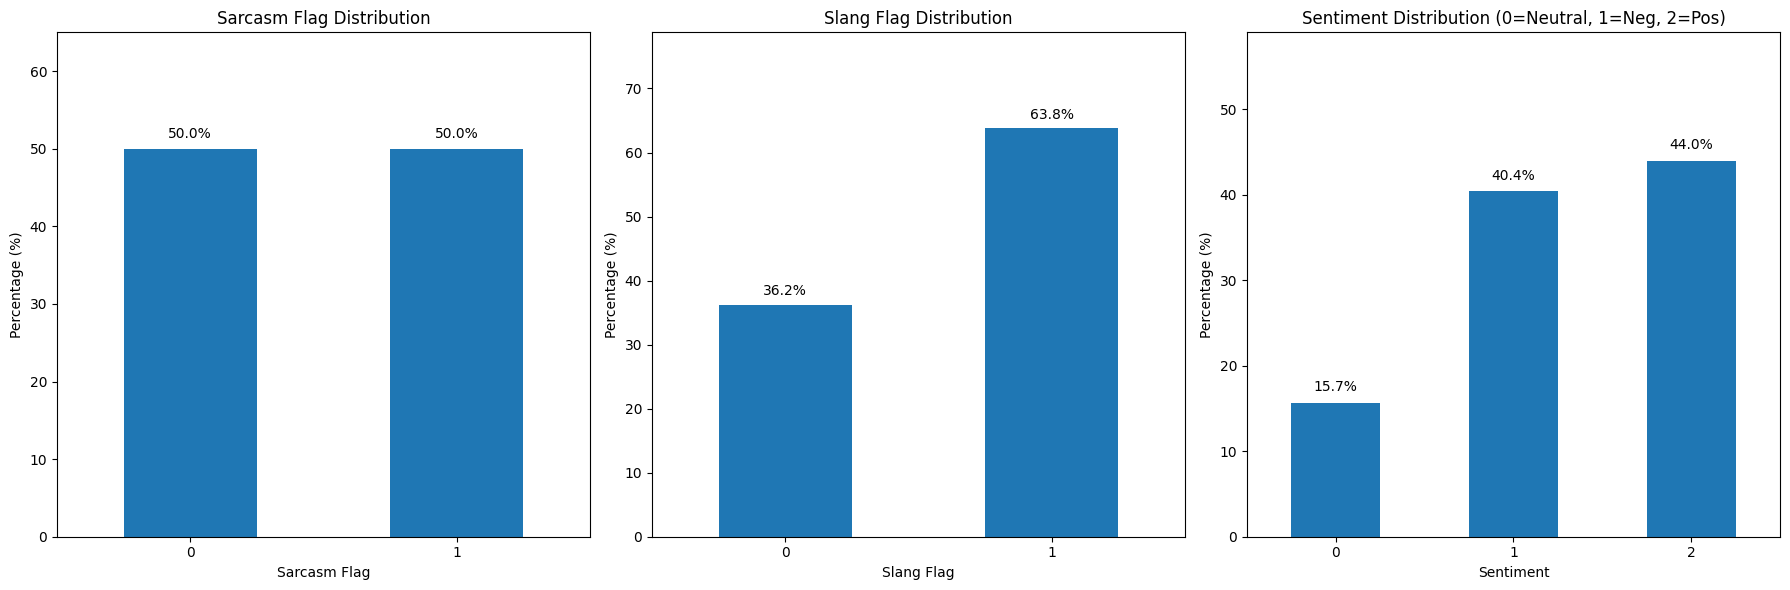

In [15]:
#Distribution plots with percentages on bars
def distribution_plots(field_name, ax, title=None):
    counts = user_comments_data[field_name].value_counts(normalize=True).sort_index() * 100
    bars = counts.plot(kind='bar', ax=ax,)

    # Add percentage labels on top of bars
    for bar in bars.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

    ax.set_title(title or f"Distribution of {field_name.replace('_', ' ').title()}")
    ax.set_xlabel(field_name.replace('_', ' ').title())
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0, max(counts) + 15)  # Give space for labels
    ax.tick_params(axis='x', rotation=0)

# Create figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Plot the three main distributions
distribution_plots('sarcasm_flag', axes[0], "Sarcasm Flag Distribution")
distribution_plots('slang_flag', axes[1], "Slang Flag Distribution")
distribution_plots('sentiment', axes[2], "Sentiment Distribution (0=Neutral, 1=Neg, 2=Pos)")

plt.tight_layout()
plt.show()

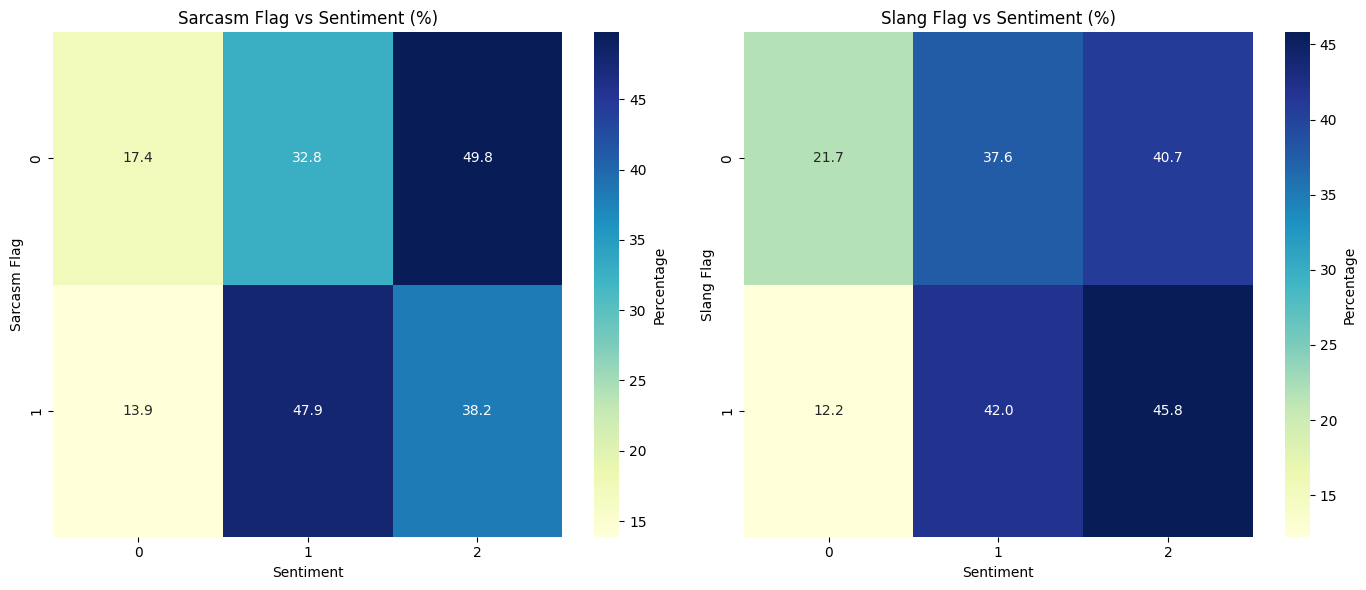

In [16]:
#Cross-tab heatmaps (very useful for your project)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sarcasm vs Sentiment
pd.crosstab(user_comments_data['sarcasm_flag'], user_comments_data['sentiment'], normalize='index') * 100
sns.heatmap(pd.crosstab(user_comments_data['sarcasm_flag'], user_comments_data['sentiment'], normalize='index') * 100,
            annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Percentage'})
axes[0].set_title("Sarcasm Flag vs Sentiment (%)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Sarcasm Flag")

# Slang vs Sentiment
sns.heatmap(pd.crosstab(user_comments_data['slang_flag'], user_comments_data['sentiment'], normalize='index') * 100,
            annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title("Slang Flag vs Sentiment (%)")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Slang Flag")

plt.tight_layout()
plt.show()


In [17]:
#metadata features
user_comments_data['text_len'] = user_comments_data['full_text'].apply(len)

In [18]:
final_user_comments = user_comments_data[['full_text','sarcasm_flag','slang_flag','slang_context','sentiment','text_len']]

In [19]:
final_user_comments

,full_text,sarcasm_flag,slang_flag,slang_context,sentiment,text_len
0,"NC and NH. [Parent: Yeah, I get that argument....",0,1,nc: Nice crib ; nh: Nice hand ; at: At your te...,2,101
1,You do know west teams play against west teams...,0,1,know: knowledge,2,219
2,"They were underdogs earlier today, but since G...",0,0,,2,155
3,"This meme isn't funny none of the ""new york ni...",0,1,are: Acronym rich environment,2,97
4,I could use one of those tools. [Parent: Yep c...,0,1,was: Wait a second,2,127
...,...,...,...,...,...,...
49994,I'm glad the state is so nice in allowing the ...,1,1,so: Significant other,1,202
49995,"But his TS% was below average, he's not even g...",1,1,was: Wait a second; 2: to,2,168
49996,"I think the man would prefer to be called ""he""...",1,0,,1,98
49997,because its console related and EVERYTHING con...,1,0,,0,146


Dataset split

In [20]:
final_user_comments = final_user_comments.dropna().reset_index(drop=True)

print("Final dataset shape:", final_user_comments.shape)
print("Sentiment distribution:\n", final_user_comments['sentiment'].value_counts(normalize=True))

#Train / Val / Test split — stratified on sentiment
train_val, test = train_test_split(
    final_user_comments,
    test_size=0.15,
    random_state=42,
    stratify=final_user_comments['sentiment']
)

train, val = train_test_split(
    train_val,
    test_size=0.1765,          # ≈ 70 / 15 / 15 overall
    random_state=42,
    stratify=train_val['sentiment']
)

Final dataset shape: (49976, 6)
Sentiment distribution:
 sentiment
2    0.439711
1    0.403674
0    0.156615
Name: proportion, dtype: float64


In [21]:
print(f"\nTrain: {len(train):,} rows")
print(f"Val:   {len(val):,} rows")
print(f"Test:  {len(test):,} rows")


Train: 34,981 rows
Val:   7,498 rows
Test:  7,497 rows


In [22]:
#TF-IDF Vectorization (fit only on train to avoid leakage)
vectorizer = TfidfVectorizer(
    max_features=8000,        # adjust based on Colab memory
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=5,                 # ignore very rare terms
    stop_words='english'
)

# Fit & transform train
X_train_text = vectorizer.fit_transform(train['full_text'])

# Transform val & test
X_val_text   = vectorizer.transform(val['full_text'])
X_test_text  = vectorizer.transform(test['full_text'])

# 4. Scale numerical metadata (text_len)
scaler = StandardScaler()
meta_cols = ['text_len']

X_train_meta = scaler.fit_transform(train[meta_cols])
X_val_meta   = scaler.transform(val[meta_cols])
X_test_meta  = scaler.transform(test[meta_cols])

# 5. Combine text + metadata features
X_train = hstack([X_train_text, X_train_meta])
X_val   = hstack([X_val_text,   X_val_meta])
X_test  = hstack([X_test_text,  X_test_meta])

# Labels
y_train = train['sentiment']
y_val   = val['sentiment']
y_test  = test['sentiment']

In [23]:
print("\nFinal feature shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)


Final feature shapes:
X_train: (34981, 8001)
X_val:   (7498, 8001)
X_test:  (7497, 8001)
